### Setup

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import time
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from pykalman import KalmanFilter


In [5]:
data_path = '../data/114228/robot_data_unified_20251106_114228.parquet'

df = pd.read_parquet(data_path, engine='fastparquet')


In [6]:
df.set_index('timestamp', inplace=True)
df = df.resample('500ms').ffill().dropna() # resampling to 2Hz
# df = df.iloc[:-100] # suction without a block at the end


In [7]:
# full loop length: 147 s
# resampled frequency: 2Hz

def plot_decomposition_period(df, vib_col_idx=None, col_name='pressure',  period=147*2, subset_start_idx=0, subset_end_idx=None, stl=False):
    
    if subset_end_idx is None:
        subset_end_idx = len(df)
    df = df.iloc[subset_start_idx:subset_end_idx]
    vib_cols = [col for col in df.columns if col.startswith('vib_')]
    if vib_col_idx is None:
        column = col_name
    else:
        column = vib_cols[vib_col_idx]
    if stl:
        decomposition = STL(df[column], period=period, robust=True).fit()
    else:
        decomposition = seasonal_decompose(df[column], period=period)
    
    fig, ax = plt.subplots(4, figsize=(12, 6))
    sns.lineplot(data=df, x=df.index, y=column, ax=ax[0])
    ax[0].set_title(column)
    sns.lineplot(data=decomposition.trend, ax=ax[1])
    ax[1].set_title('Trend')
    sns.lineplot(data=decomposition.seasonal, ax=ax[2])
    ax[2].set_title('Seasonal')
    sns.lineplot(data=decomposition.resid, ax=ax[3])
    ax[3].set_title('Residual')
    plt.tight_layout()
    plt.show()
    
    

In [8]:
def plot_autocorelation(df, vib_col_idx=None, col_name='pressure', partial=False, lags=20):
    
    vib_cols = [col for col in df.columns if col.startswith('vib_')]
    if vib_col_idx is None:
        column = col_name
    else:
        column = vib_cols[vib_col_idx]
        
    ts = df[column]
    if partial:
        results = pacf(ts, nlags=lags)
        plot_pacf(ts, lags=lags)
    else:
        results = acf(ts, nlags=lags)
        plot_acf(ts, lags=lags)
        
    return results

### Plots

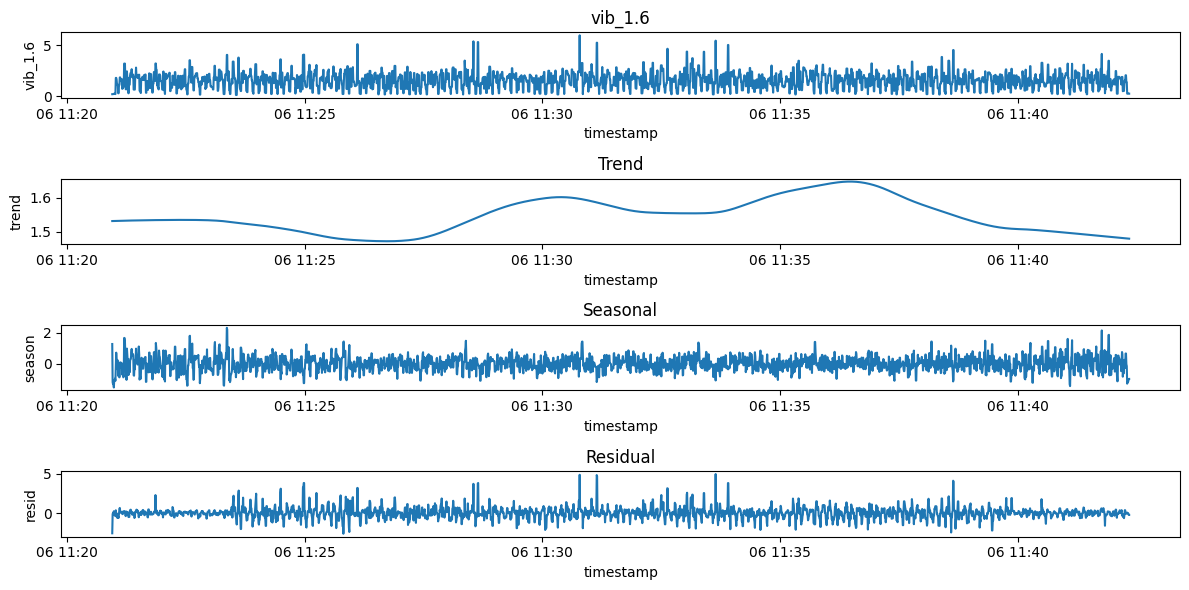

In [9]:
plot_decomposition_period(df, vib_col_idx=3, stl=True)

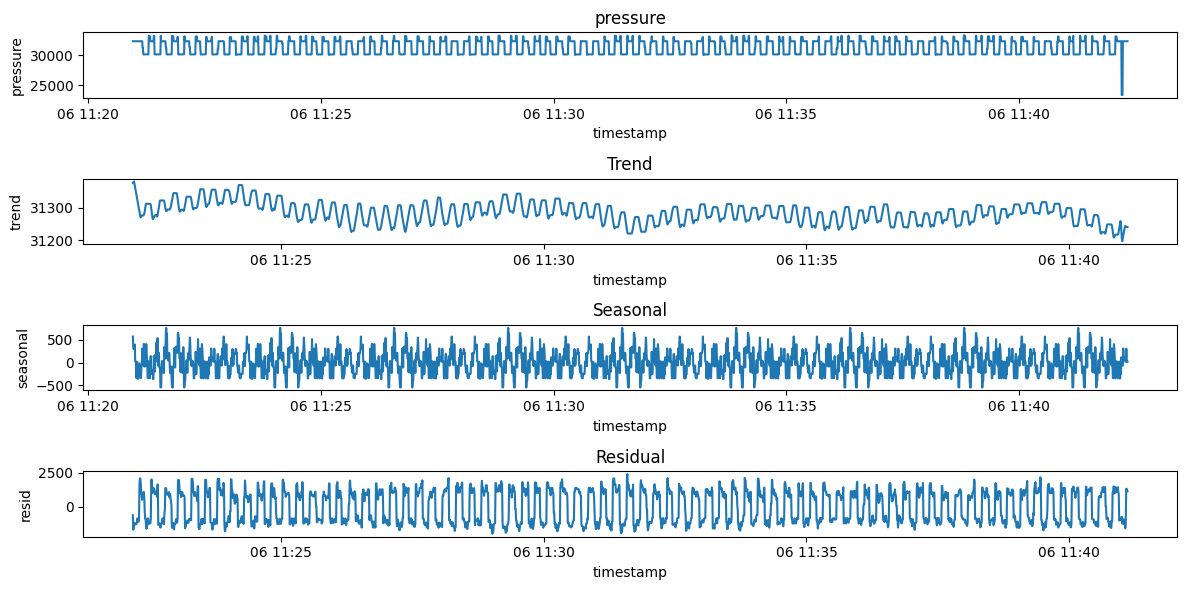

In [10]:
plot_decomposition_period(df)

In [11]:
def check_stationarity(df, p_value_threshold = 0.05):
    
    df = df.select_dtypes('number')
    
    if df.isna().sum().sum() > 0.2*len(df):
        print('Too many empty values')
        return None
    
    results = {}
    
    for col in df.columns:
        if len(df[col].value_counts()) != 1:
            adf_res = adfuller(df[col].dropna())
            # print(adf_res)
            p_value = adf_res[1]
            is_stat = bool(p_value <= p_value_threshold)
            results[col] = (is_stat, p_value)
    
    return results

# Test your robot data
# Original pressure data
is_stationary = check_stationarity(df)

is_stationary

{'j1': (True, 5.311533252303155e-16),
 'j2': (False, 0.060910486624930614),
 'j3': (True, 0.005461102662244575),
 'j4': (True, 0.0008350659139355677),
 'j5': (True, 0.010580238009198927),
 'j6': (True, 0.030870476635301992),
 'rpi_temp': (False, 0.07258748086950498),
 'motor1_temp': (False, 0.07258748086950498),
 'motor2_temp': (False, 0.42901689559799727),
 'motor3_temp': (False, 0.27025555923491473),
 'motor4_temp': (True, 9.822337506980453e-06),
 'motor5_temp': (True, 0.0417292149567513),
 'motor6_temp': (True, 0.009807235530222223),
 'avg_motor_temp': (False, 0.5801373752976886),
 'max_motor_temp': (False, 0.09343932743753258),
 'motor1_voltage': (True, 5.83596707430857e-05),
 'motor2_voltage': (True, 5.259648373880209e-05),
 'motor3_voltage': (True, 0.00020646764943316862),
 'motor4_voltage': (True, 0.0),
 'motor5_voltage': (True, 0.0),
 'motor6_voltage': (True, 9.706147153434077e-27),
 'avg_motor_voltage': (True, 7.449508919689476e-09),
 'pressure': (True, 1.5412498996270688e-24)

<Axes: xlabel='timestamp'>

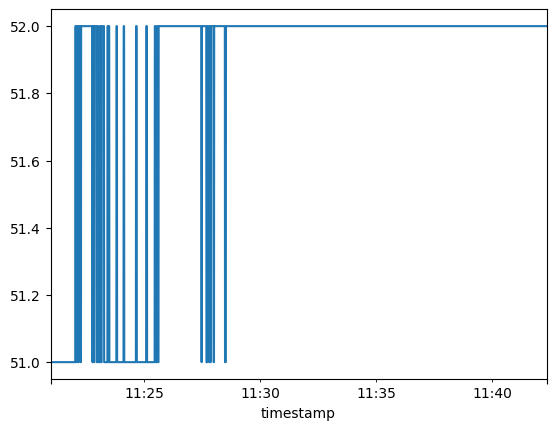

In [12]:
df['motor1_temp'].plot()

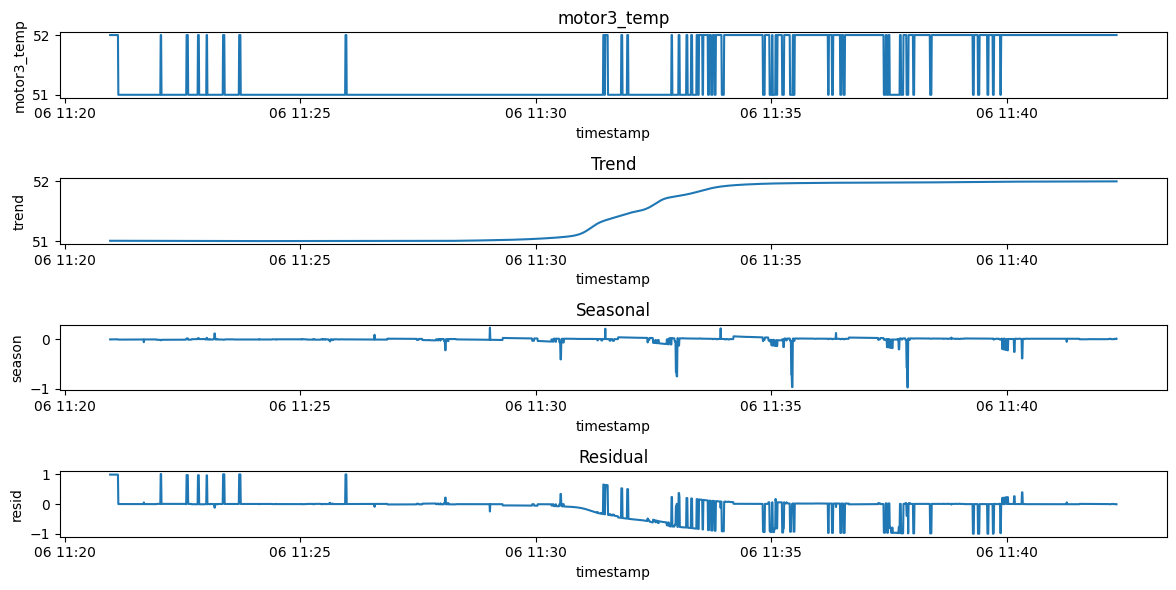

In [28]:

plot_decomposition_period(df, col_name='motor3_temp', stl=True)

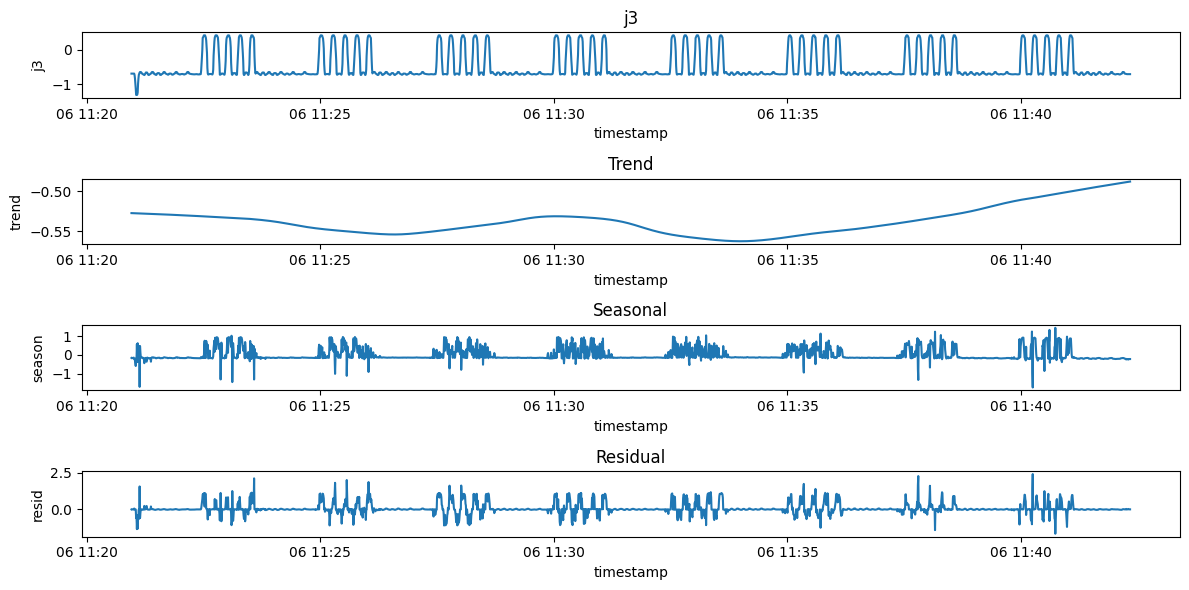

In [19]:

plot_decomposition_period(df, col_name='j3', stl=True)

In [14]:
def apply_kalman_filtering(df, column):
    series = df[column]

    kf = KalmanFilter(
        initial_state_mean=series.iloc[0],
        n_dim_obs=1,
        n_dim_state=1,
        transition_matrices=[1],
        observation_matrices=[1],
        transition_covariance=0.1,
        observation_covariance=1.0,
    )
    
    return kf.filter(series)


filtered_means, filter_covariance = apply_kalman_filtering(df, 'pressure')

In [40]:
filtered_means_temp, filter_covariance_temp = apply_kalman_filtering(df, 'motor3_temp')

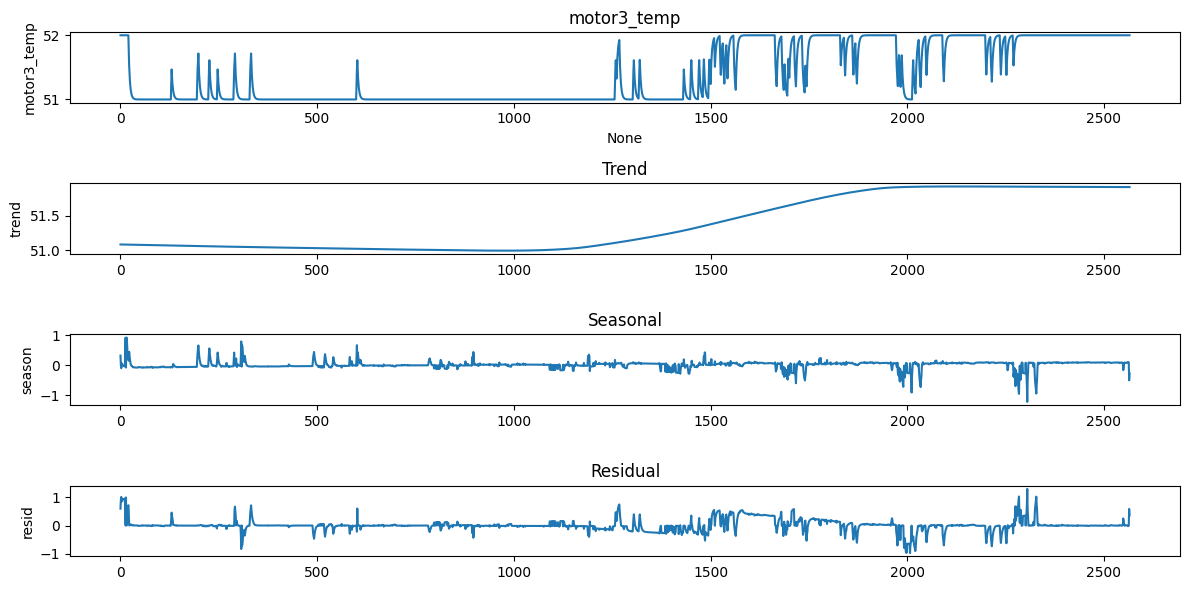

In [41]:
plot_decomposition_period(pd.DataFrame(data=filtered_means_temp, columns=['motor3_temp']), col_name='motor3_temp', stl=True)

array([1.        , 0.92579089, 0.85158179, 0.79372908, 0.77349609,
       0.76634821, 0.7657429 , 0.76840887, 0.77271047, 0.77210516,
       0.76332165, 0.75453813, 0.74575462, 0.75332751, 0.75926475,
       0.75375252, 0.74824029, 0.74599933, 0.74702966, 0.74315307,
       0.74091211])

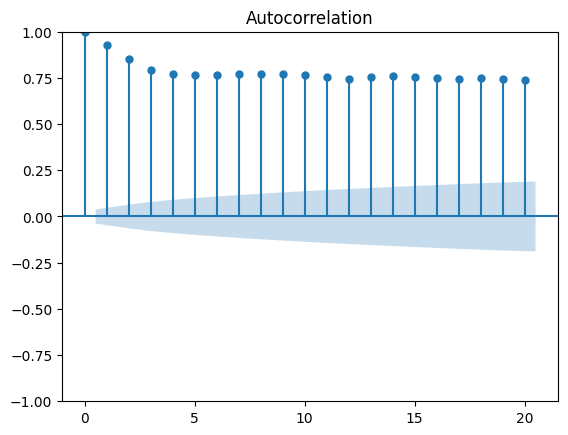

In [29]:
plot_autocorelation(df, col_name='motor3_temp')

array([ 1.        ,  0.93340588,  0.78058605,  0.58546013,  0.38391716,
        0.20573175,  0.06941651, -0.01149977, -0.03335546, -0.00336424,
        0.05253489,  0.11306938,  0.15997445,  0.1828868 ,  0.18633799,
        0.17837042,  0.16572405,  0.14969984,  0.12677144,  0.09484884,
        0.05425666])

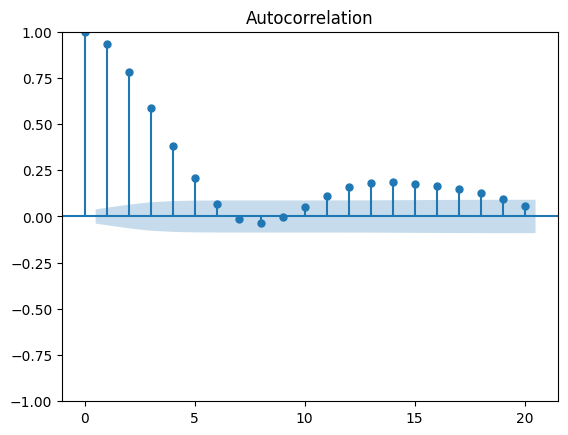

In [25]:
plot_autocorelation(df, col_name='j5')

⏱️ TIMING COMPARISON:
[ 1.00000000e+00  4.82466346e-01  9.82247905e-02 -3.06224308e-02
 -7.97854070e-02 -5.09117182e-02 -1.44030350e-03 -7.73030133e-03
 -3.51755976e-02 -3.54376848e-02 -2.54338036e-02 -7.23802218e-04
  1.87337596e-02  5.05849936e-02  1.02439934e-01  1.22420848e-01
  1.12952899e-01  8.97535409e-02  4.17502234e-02 -4.58567545e-02
 -7.98202501e-02 -7.84092566e-02 -9.70852558e-02 -9.21470900e-02
 -5.00835264e-02  1.59399213e-02  8.97595404e-03 -5.25604500e-02
 -8.66015351e-03  9.92049641e-02  1.63428728e-01  2.03542929e-01
  1.13769233e-01 -4.04629140e-02 -6.46755655e-02 -3.27375535e-02
 -2.33749728e-02 -2.97884156e-02 -2.95892934e-02 -4.09872803e-02
 -5.84076342e-02 -4.77904924e-02 -9.78464898e-03  4.14385345e-02
  5.67525490e-02  5.42308158e-02  6.75469532e-02  5.08850434e-02
  1.96722913e-02 -6.32725550e-03 -4.58842668e-02]
Without FFT: 0.0028 seconds
With FFT: 0.0003 seconds
Speedup: 8.66x faster
Max difference: 2.78e-16


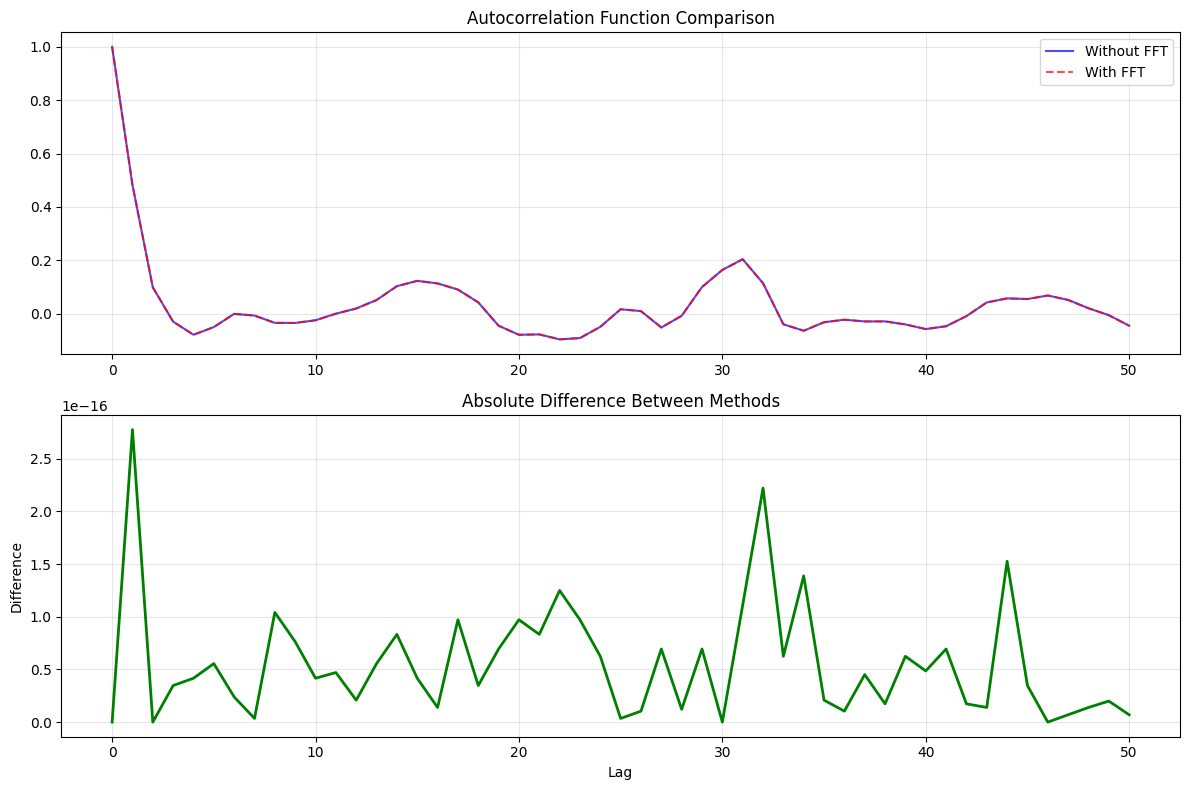

In [17]:
from statsmodels.tsa.stattools import acf
import numpy as np
import matplotlib.pyplot as plt

def demonstrate_fft_in_acf(df, column='pressure'):
    """
    Show the difference between FFT and non-FFT autocorrelation calculation
    """
    data = df[column].dropna()
    max_lags = min(50, len(data)//4)
    
    print("⏱️ TIMING COMPARISON:")
    print("=" * 40)
    
    # Method 1: Without FFT (slower, direct calculation)
    import time
    start = time.time()
    acf_no_fft = acf(data, nlags=max_lags, fft=False)
    print(acf_no_fft)
    time_no_fft = time.time() - start
    
    # Method 2: With FFT (faster)
    start = time.time()
    acf_with_fft = acf(data, nlags=max_lags, fft=True)
    time_with_fft = time.time() - start
    
    print(f"Without FFT: {time_no_fft:.4f} seconds")
    print(f"With FFT: {time_with_fft:.4f} seconds")
    print(f"Speedup: {time_no_fft/time_with_fft:.2f}x faster")
    
    # Compare results (should be nearly identical)
    difference = np.abs(acf_no_fft - acf_with_fft)
    print(f"Max difference: {difference.max():.2e}")
    
    # Plot comparison
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # ACF comparison
    axes[0].plot(acf_no_fft, 'b-', label='Without FFT', alpha=0.7)
    axes[0].plot(acf_with_fft, 'r--', label='With FFT', alpha=0.7)
    axes[0].set_title('Autocorrelation Function Comparison')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Difference plot
    axes[1].plot(difference, 'g-', linewidth=2)
    axes[1].set_title('Absolute Difference Between Methods')
    axes[1].set_xlabel('Lag')
    axes[1].set_ylabel('Difference')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Test with your data
demonstrate_fft_in_acf(df, 'vib_12.5')

In [47]:
col_to_filter = 'vib_4.7'

Text(0.5, 1.0, 'vib_4.7')

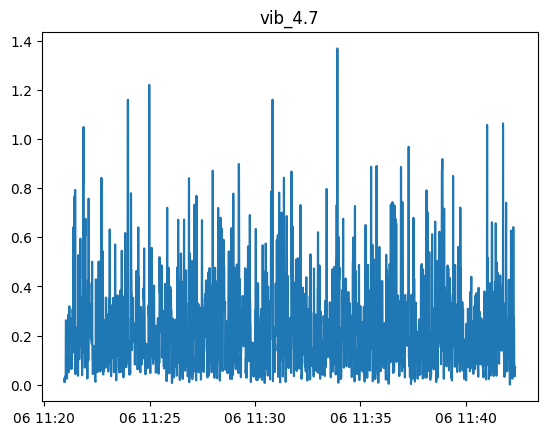

In [52]:
plt.plot(df[col_to_filter])
plt.title(col_to_filter)

Text(0.5, 1.0, 'vib_4.7 Filtered')

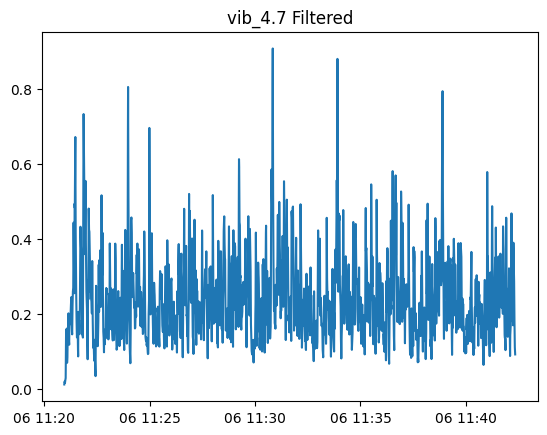

In [58]:
filtered_means_col, filter_covariance_col = apply_kalman_filtering(df, col_to_filter)

filtered_df = pd.DataFrame(data=filtered_means_col, columns=[col_to_filter], index=df.index)


plt.plot(filtered_df)
plt.title(col_to_filter + ' Filtered')
